## Best Optimization CV - Employer Bee Algo 2 + Onlooker Bee Algo 3

In [1]:
from Pipeline.Algorithm.ArtificialBeeColonyElmCV import ArtificialBeeColonyElmCV
from Pipeline.Global.GallstoneDataSet import GallstoneDataSet
from Pipeline.Global.GlobalSetting import GlobalSetting
from Pipeline.Global.Plotting import Plotting
from Pipeline.Methodology.ABC_Testing import abc_testing

In [2]:
fold_id = 4
mod = f"Grid_Optimization_Fold_{fold_id}"

gallstone_dataset = GallstoneDataSet()
gallstone_dataset.fetch_data_path_1()
gallstone_dataset.cross_validate_test(5)

x_train, y_train, x_test, y_test = gallstone_dataset.fold_split[fold_id]

features_size = x_train.shape[1]

In [3]:
best_lambda_config = GlobalSetting.get_config_by_type("Grid_Optimization")
best_lambda_hidden_size = best_lambda_config["Hidden_Nodes"] if best_lambda_config else None
best_lambda_lambda_value = best_lambda_config["Lambda_Value"] if best_lambda_config else None

In [4]:
abc_r_elm_cv  = ArtificialBeeColonyElmCV(
    features_size       = features_size,
    hidden_size         = best_lambda_hidden_size,
    activation_function = GlobalSetting.sigmoid             ,
    regularization_lambda=best_lambda_lambda_value           ,
    fitness_function    = GlobalSetting.evaluation_function ,
    solution_size       = GlobalSetting.solution_size       ,
    trial_limit         = GlobalSetting.trial_limit         ,
    max_iteration       = GlobalSetting.max_iteration
)
abc_r_elm_cv.employed_bee_apply_algo3()
abc_r_elm_cv.onlooker_bee_apply_algo2()

In [5]:
results_df , convergence_df , scout_df = abc_testing(abc_r_elm_cv, x_train, y_train, x_test, y_test)
results_df.describe()


Running simulation for Seed: 161...
Iteration 003 complete | Duration: 0.1094s | Scout Triggers: 4 | Best Fitness: 0.732753

Running simulation for Seed: 162...
Iteration 003 complete | Duration: 0.0936s | Scout Triggers: 3 | Best Fitness: 0.723674

Running simulation for Seed: 163...
Iteration 003 complete | Duration: 0.1064s | Scout Triggers: 5 | Best Fitness: 0.725977

Running simulation for Seed: 164...
Iteration 003 complete | Duration: 0.0920s | Scout Triggers: 4 | Best Fitness: 0.708629

Running simulation for Seed: 165...
Iteration 003 complete | Duration: 0.0851s | Scout Triggers: 3 | Best Fitness: 0.715647

Running simulation for Seed: 166...
Iteration 003 complete | Duration: 0.0910s | Scout Triggers: 5 | Best Fitness: 0.730546

Running simulation for Seed: 167...
Iteration 003 complete | Duration: 0.0871s | Scout Triggers: 4 | Best Fitness: 0.731693

Running simulation for Seed: 168...
Iteration 003 complete | Duration: 0.0691s | Scout Triggers: 3 | Best Fitness: 0.722197


,Accuracy,Precision,Recall,NPV,Specificity,F1-Score,F2-Score,Bal Accuracy,MCC,ABC_Seed
count,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000
mean,0.827513,0.849110,0.791398,0.812472,0.862500,0.817842,0.801477,0.826949,0.657706,175.500000
std,0.031397,0.034897,0.059742,0.043219,0.036332,0.036927,0.050125,0.031675,0.062011,8.803408
min,0.761905,0.785714,0.677419,0.729730,0.812500,0.736842,0.700000,0.760585,0.525365,161.000000
25%,0.809524,0.827586,0.774194,0.790635,0.843750,0.800000,0.780494,0.808972,0.620678,168.250000
50%,0.841270,0.847801,0.790323,0.809028,0.875000,0.826492,0.800577,0.839970,0.682460,175.500000
75%,0.841270,0.872917,0.838710,0.842490,0.875000,0.838710,0.837366,0.841230,0.687408,182.750000
max,0.888889,0.920000,0.903226,0.903226,0.937500,0.888889,0.897436,0.889113,0.778226,190.000000


[I/O Trace] Figure exported successfully: ../../Storage/Figure\ABC_Telemetry_Grid_Optimization_Fold_4_MCC.png


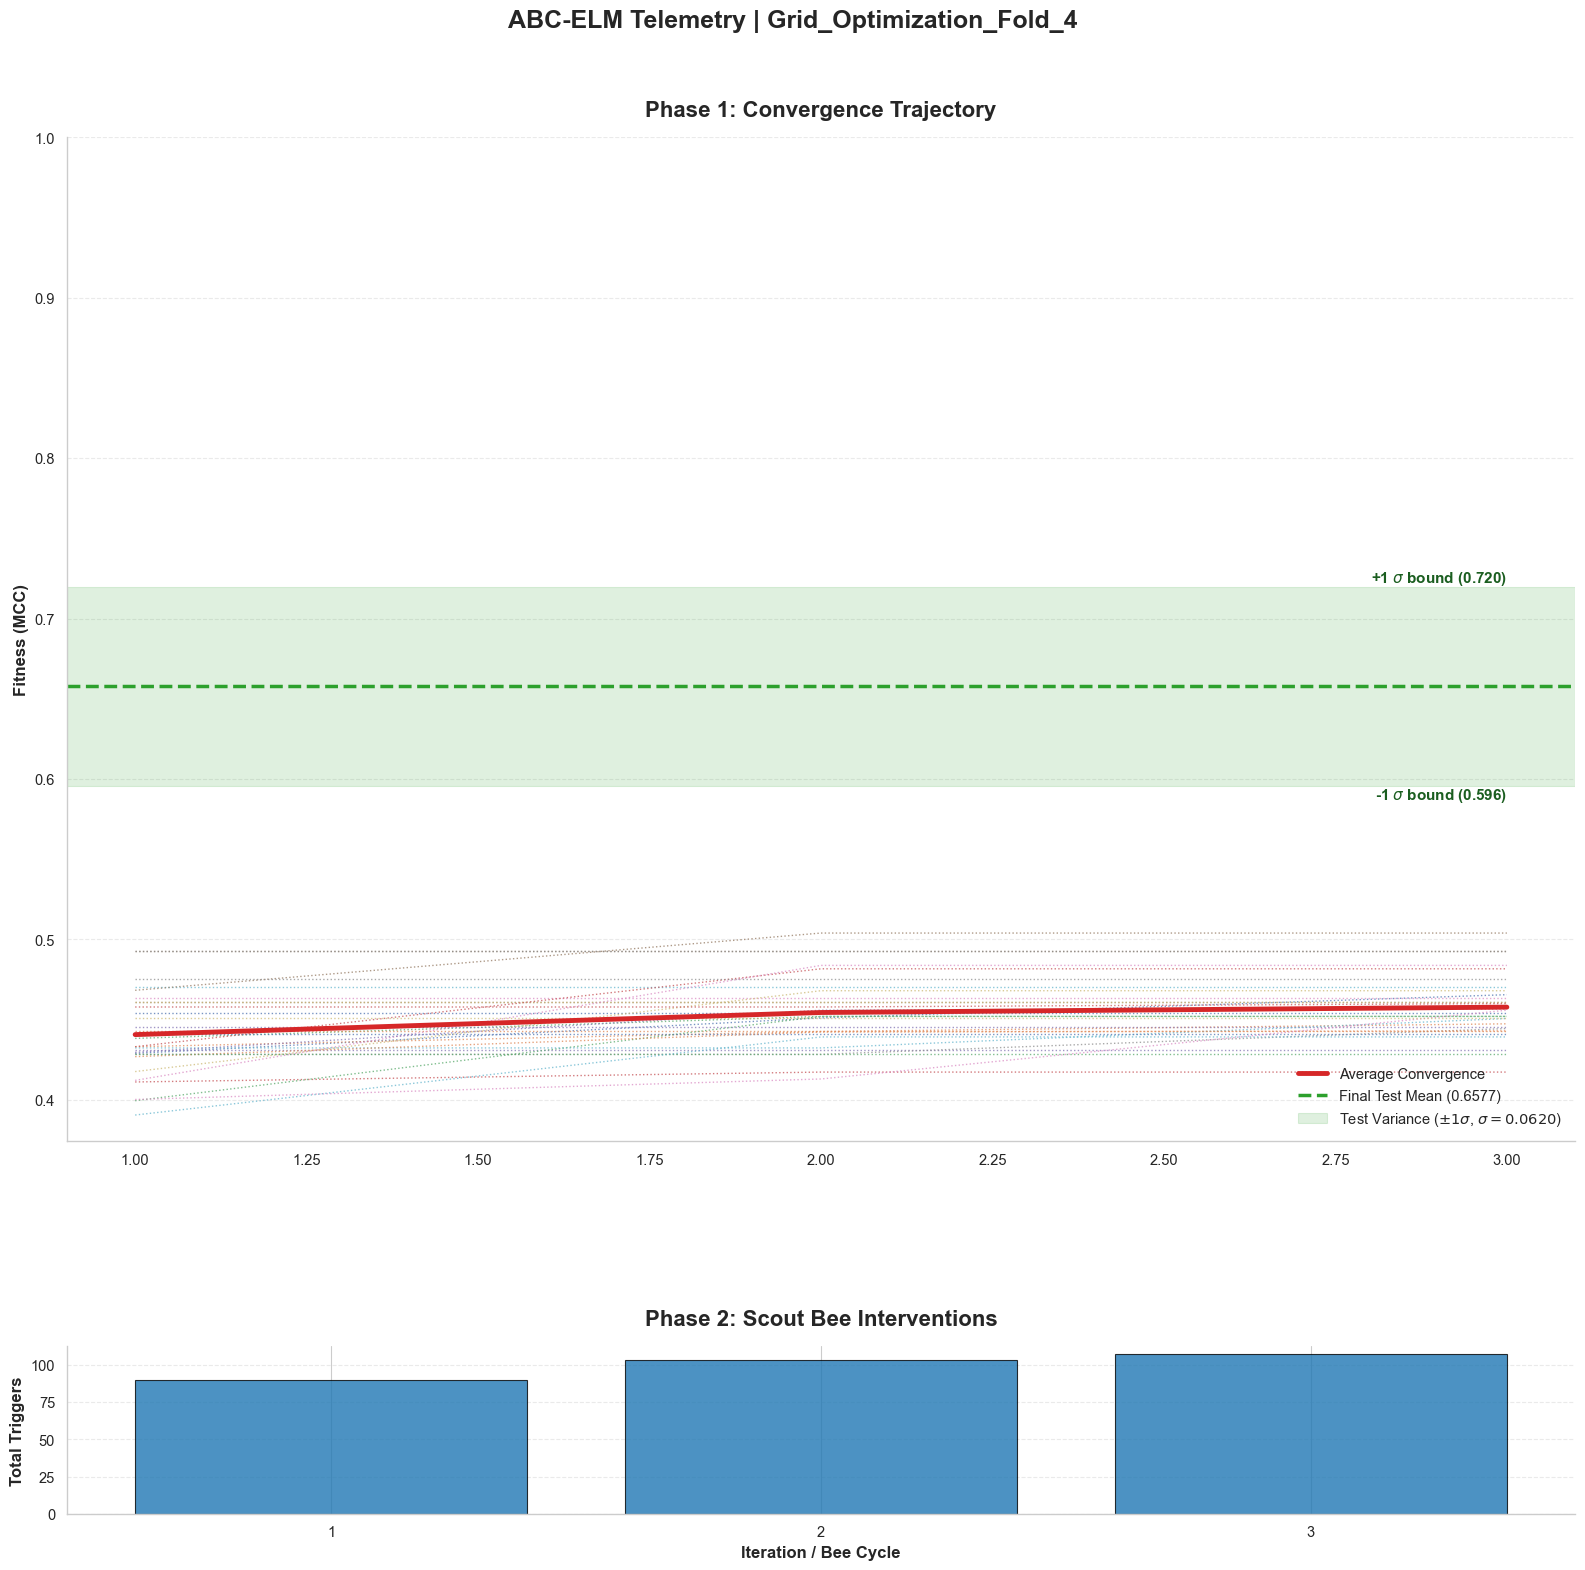

In [6]:
Plotting.plot_abc_dashboard(convergence_df,scout_df,mod,results_df=results_df,is_final_record=True)

In [7]:
GlobalSetting.save_dataframe_to_record(results_df, f"ABC_{mod}_Results.csv")
GlobalSetting.save_dataframe_to_record(convergence_df, f'ABC_{mod}_Convergence.csv')
GlobalSetting.save_dataframe_to_record(scout_df, f'ABC_{mod}_Scout_History.csv')

[I/O Trace] Record exported successfully: ../../Storage/Record\ABC_Grid_Optimization_Fold_4_Results.csv
[I/O Trace] Record exported successfully: ../../Storage/Record\ABC_Grid_Optimization_Fold_4_Convergence.csv
[I/O Trace] Record exported successfully: ../../Storage/Record\ABC_Grid_Optimization_Fold_4_Scout_History.csv
